## CKD Dataset Project ML Modeling

#### import Librires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Reasing Dataset

In [2]:
df_train = pd.read_csv('Training_CKD_dataset.csv')

In [3]:
df_test = pd.read_csv('Testing_CKD_dataset.csv')

### EDA

In [4]:
df_train.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No


### Checking Nulls

In [5]:
df_train.isnull().sum()

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes                    0
Hypertensi

In [6]:
df_train.describe()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,51.951905,0.500619,25.977571,113.497619,75.280857,84.280714,0.629571,21.682048,91.426095,59.986905,...,7493.323000,300422.551571,42.167238,134.330524,99.473762,6.998247,214.411762,199.511571,3.598048,6.507856
std,18.796090,0.500012,4.890439,19.151820,12.106952,14.387748,1.482399,20.800122,26.787045,136.148540,...,2019.807219,86546.236256,5.496877,37.623833,17.300907,1.736593,37.451581,58.167742,0.764034,0.865395
min,20.000000,0.000000,18.000000,90.000000,60.000000,60.000000,0.000000,7.000000,5.000000,0.000000,...,4000.000000,150022.000000,20.000000,70.000000,70.000000,4.000855,150.000000,100.000000,1.000000,5.000065
25%,36.000000,0.000000,22.000000,99.000000,66.000000,72.000000,0.000000,11.000000,89.000000,6.000000,...,5738.000000,225571.000000,40.000000,102.000000,84.000000,5.509804,182.000000,149.000000,3.000000,5.757357
50%,52.000000,1.000000,26.000000,110.000000,73.000000,84.000000,0.000000,15.000000,99.000000,13.000000,...,7504.000000,300718.000000,43.000000,134.000000,99.000000,7.002234,214.000000,199.000000,4.000000,6.520847
75%,68.000000,1.000000,30.000000,120.000000,80.000000,97.000000,1.000000,20.000000,109.000000,20.000000,...,9234.000000,375397.250000,46.000000,167.000000,114.000000,8.501457,247.000000,250.000000,4.000000,7.254656
max,84.000000,1.000000,34.000000,189.000000,119.000000,109.000000,9.000000,149.000000,119.000000,999.000000,...,10999.000000,449942.000000,49.000000,199.000000,129.000000,9.999904,279.000000,299.000000,4.000000,7.999568


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium

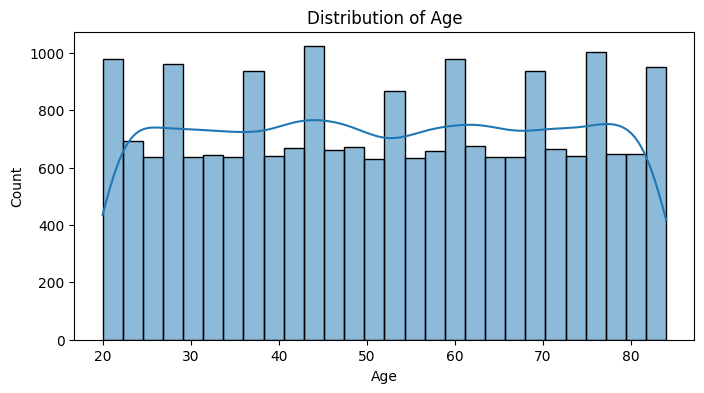

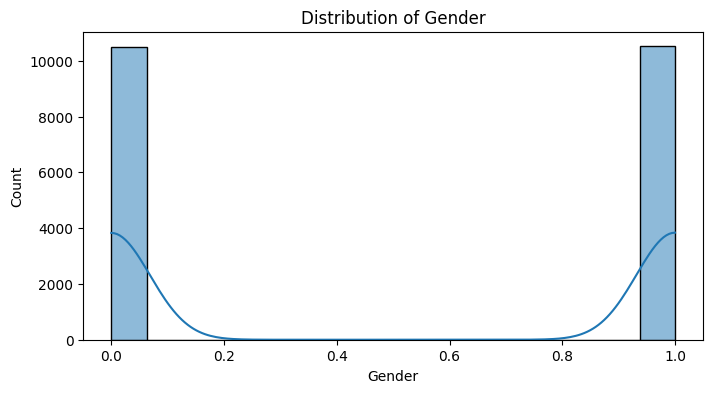

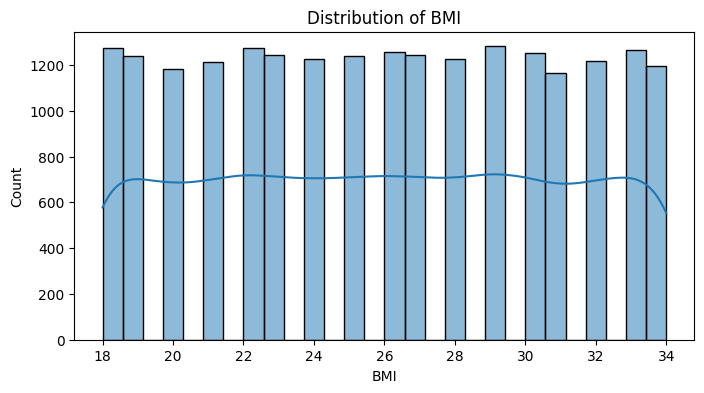

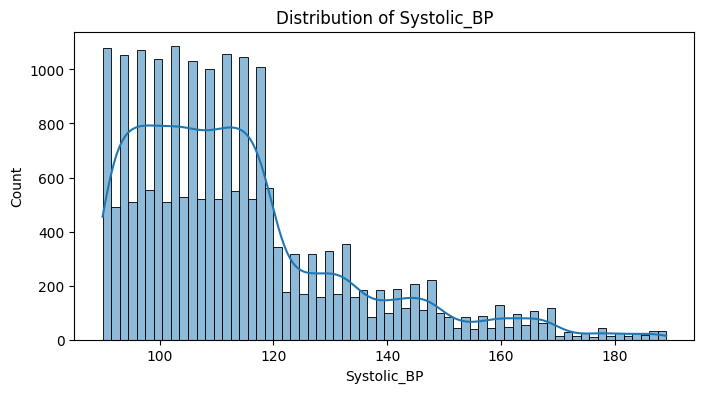

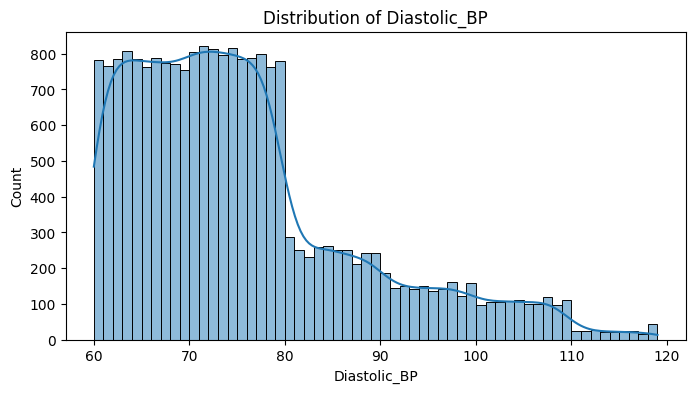

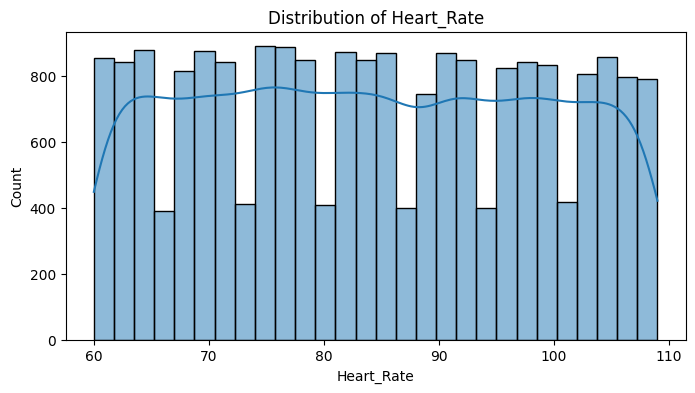

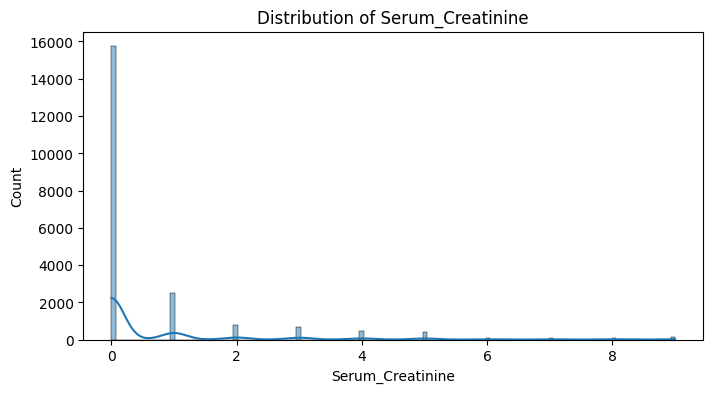

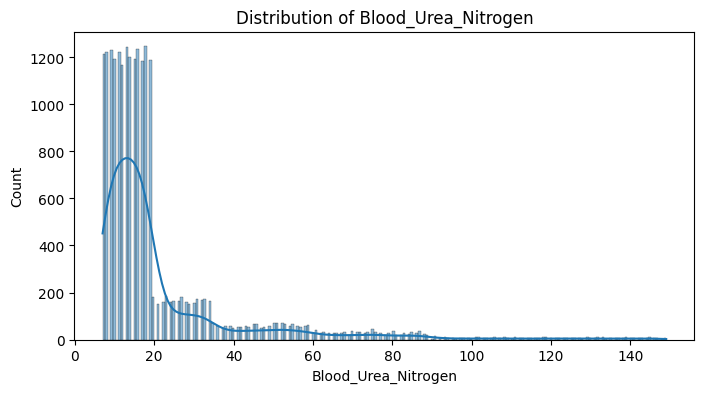

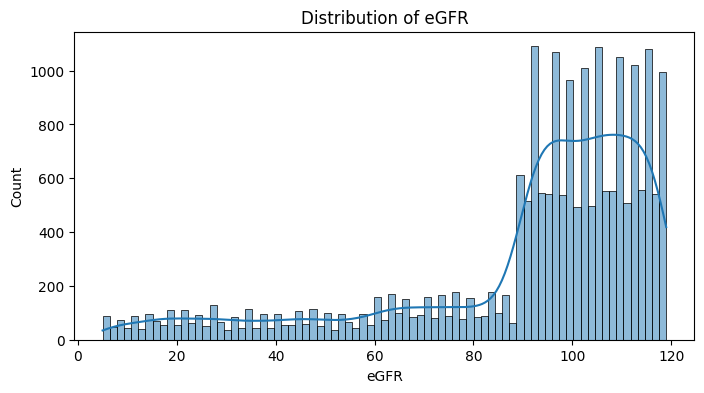

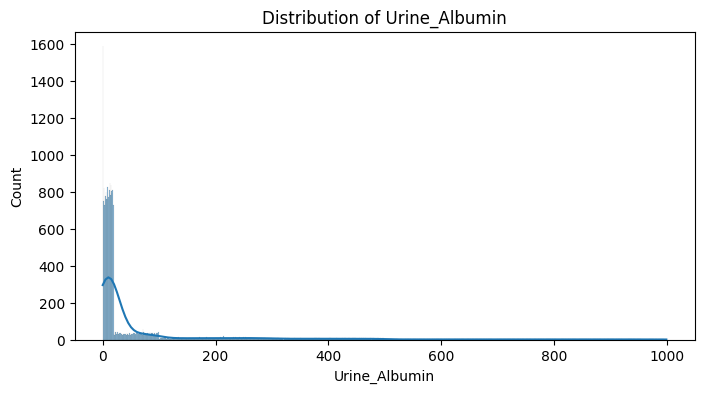

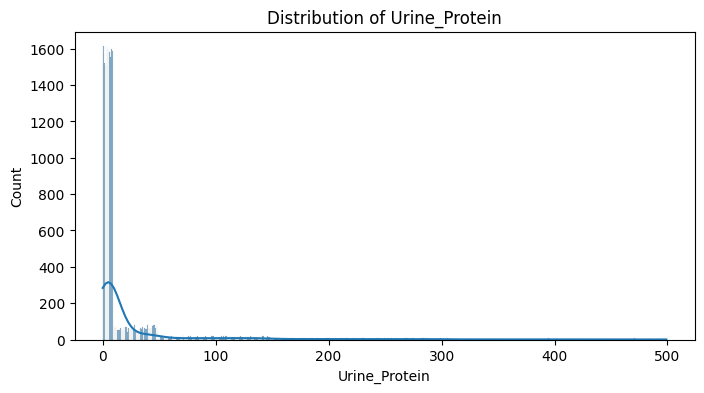

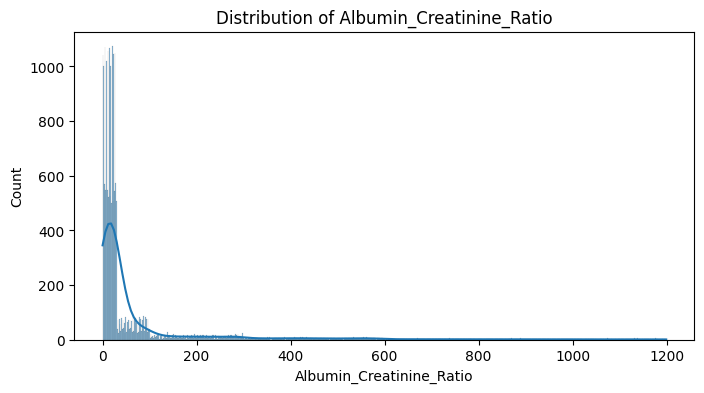

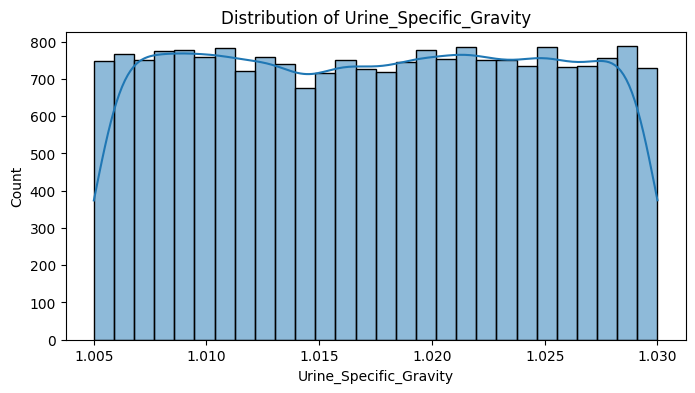

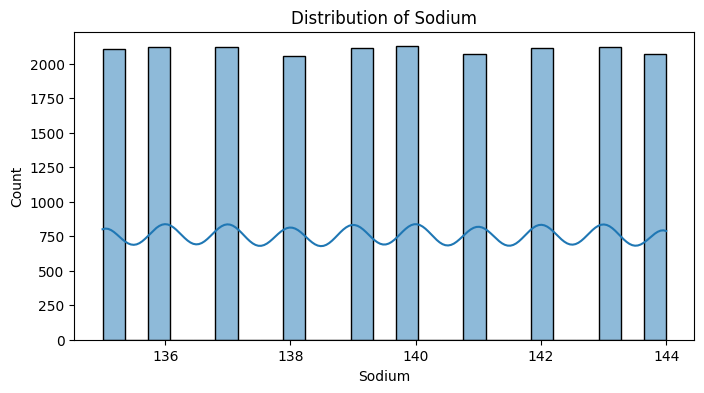

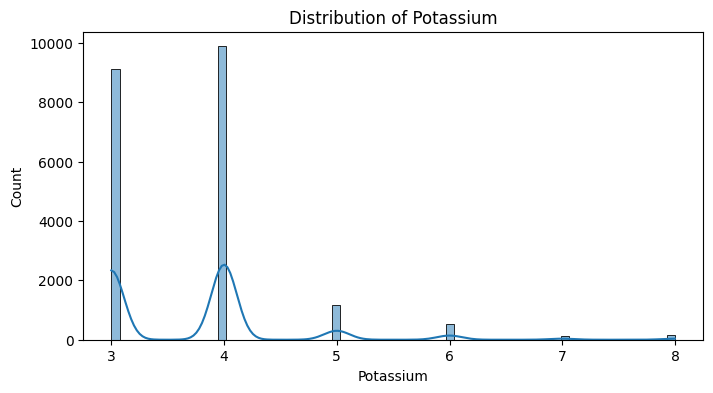

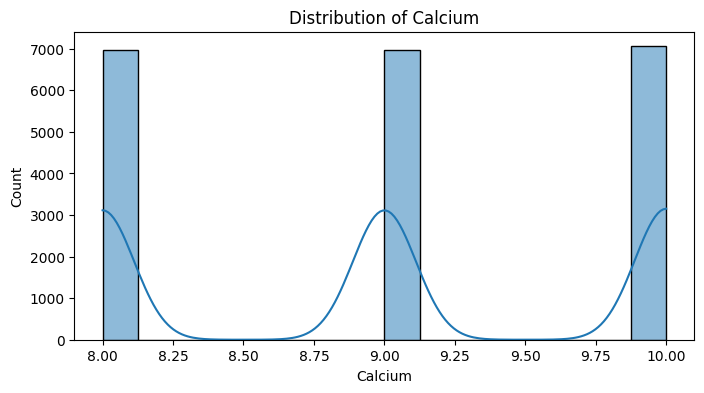

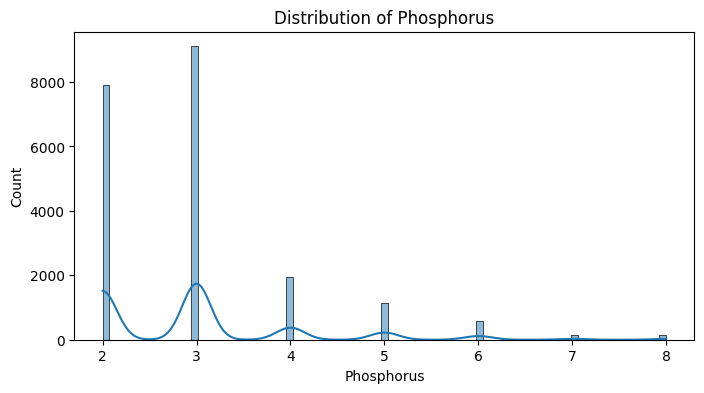

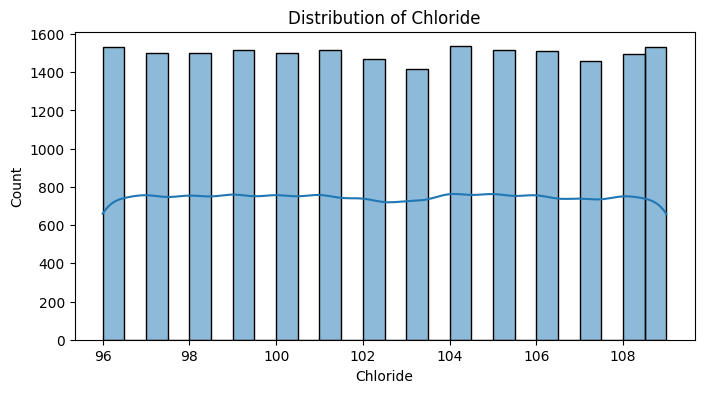

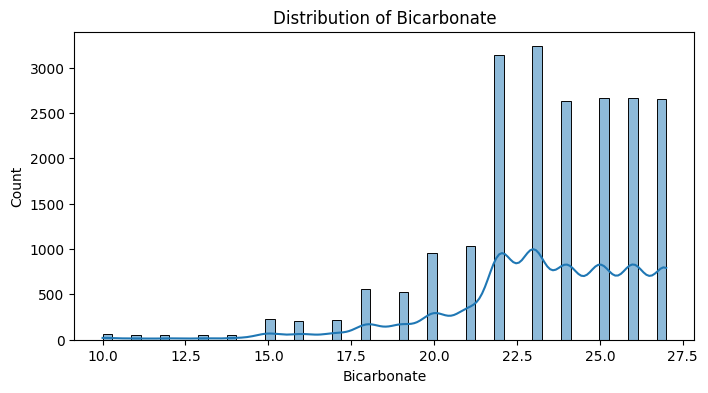

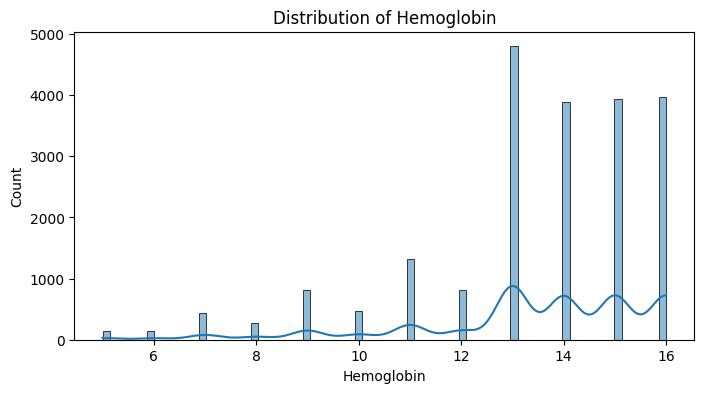

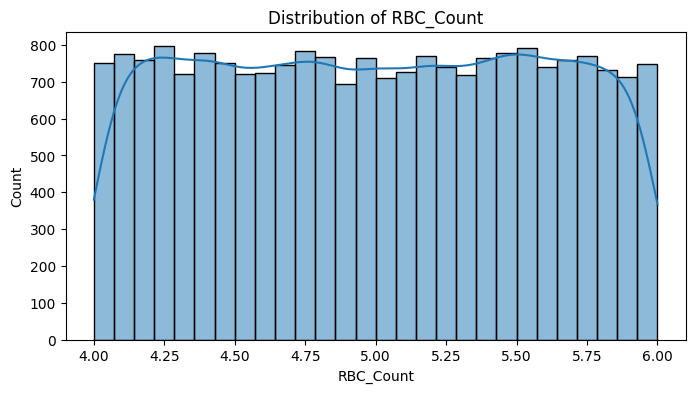

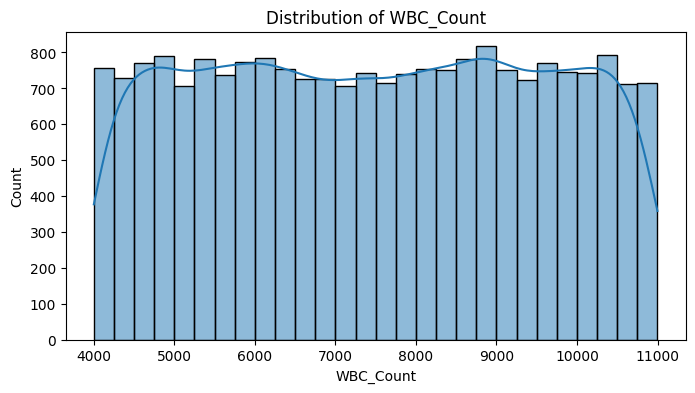

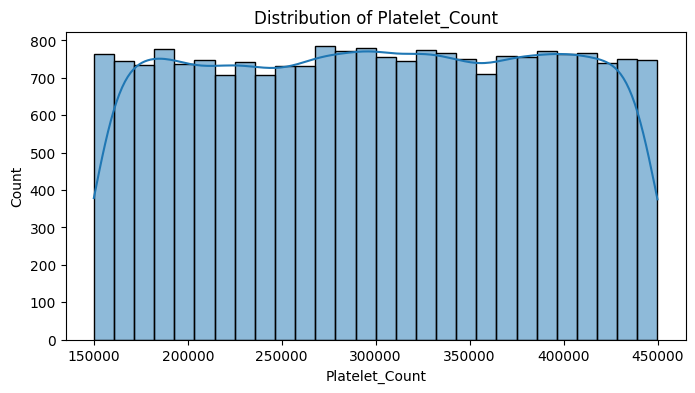

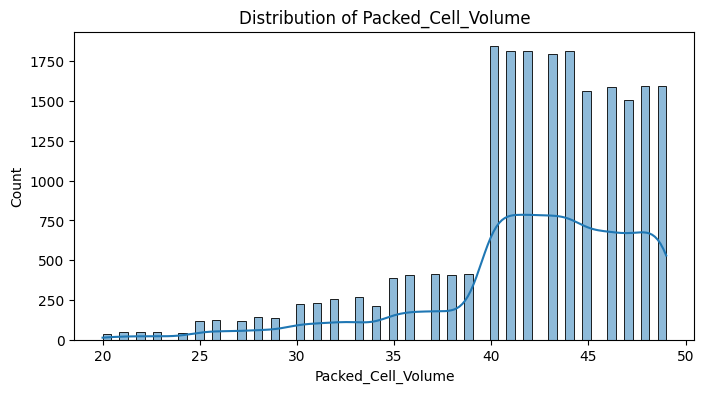

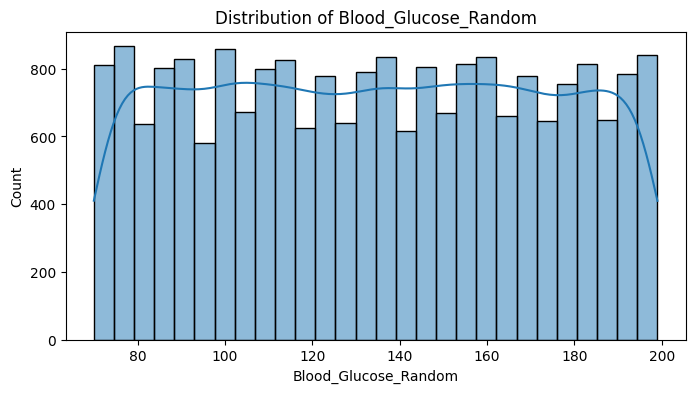

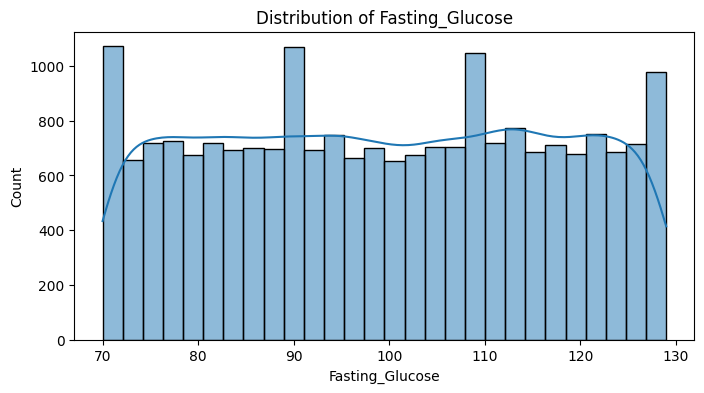

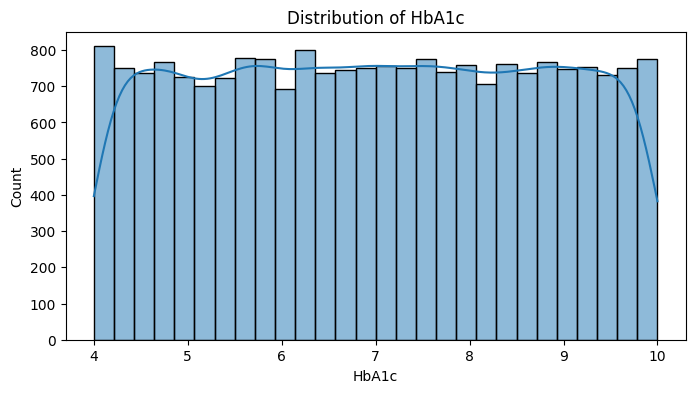

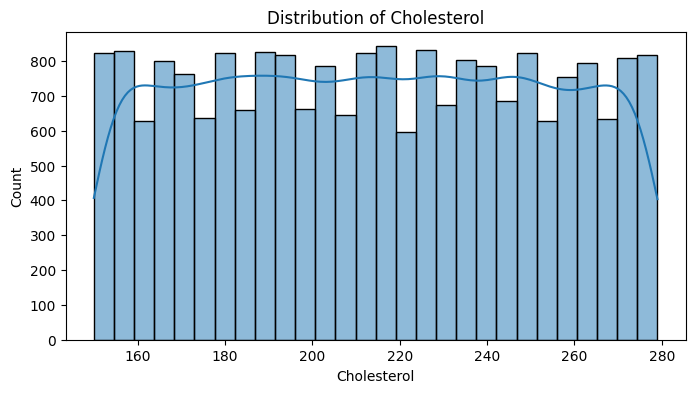

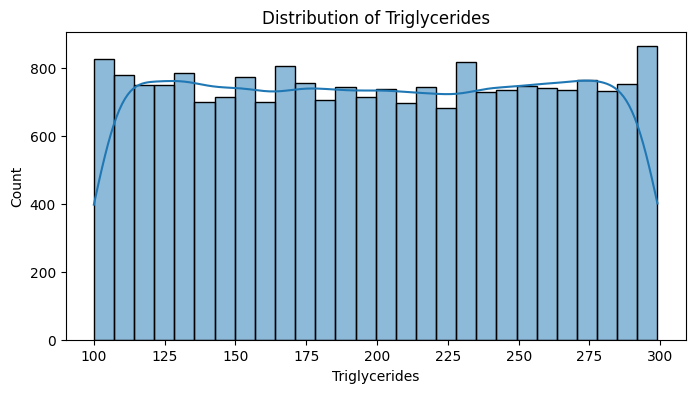

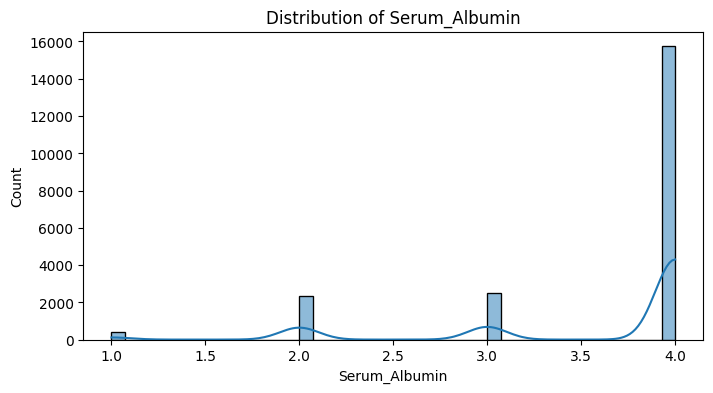

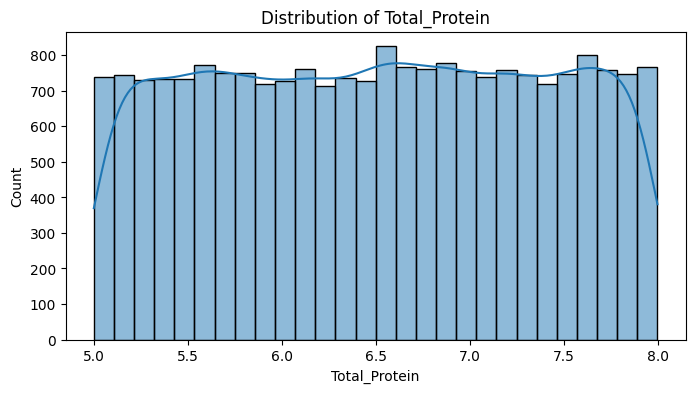

In [8]:
#plot distribution of all numeric features
numeric_features = df_train.select_dtypes(include=[np.number]).columns
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

### it seem that data is tends to both `left skeweness` and `uniform distruption`

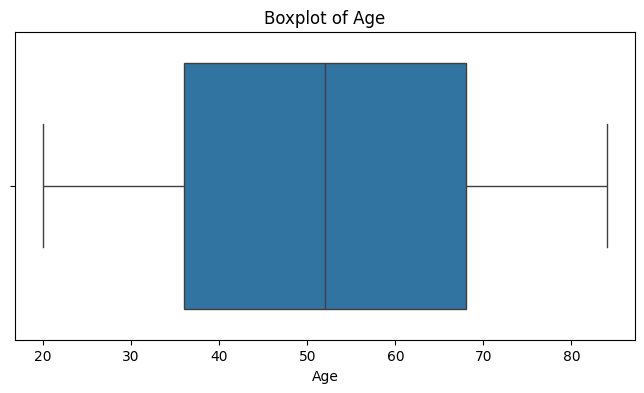

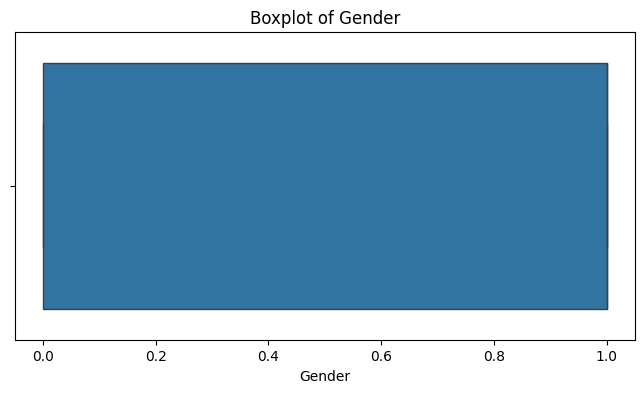

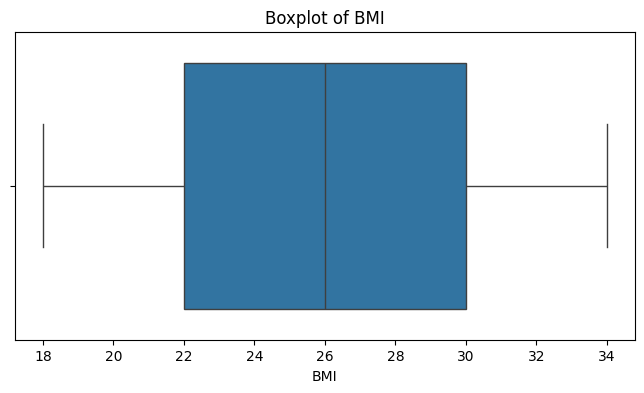

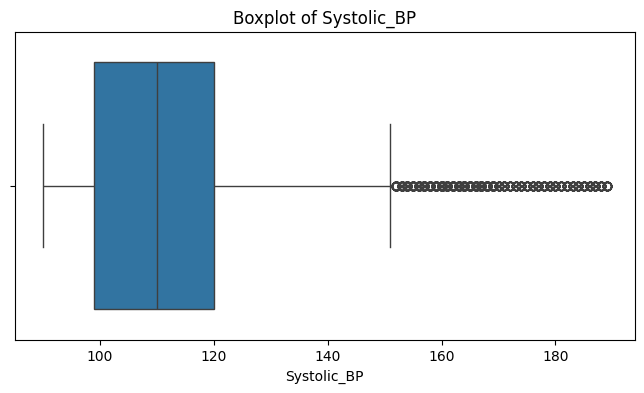

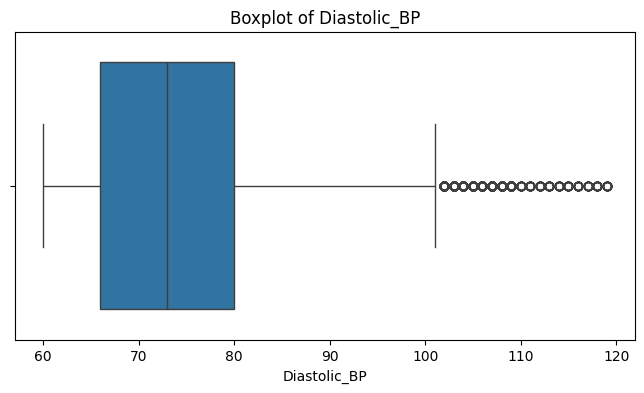

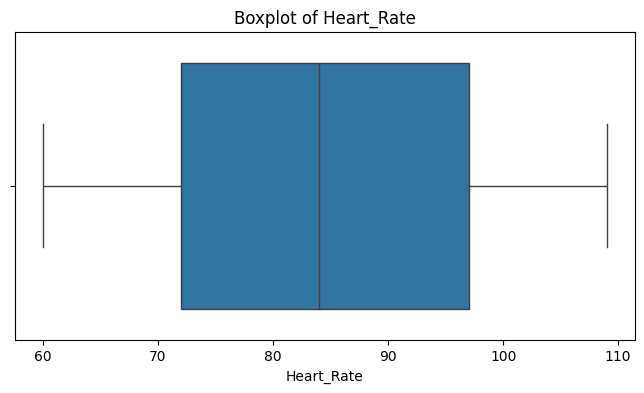

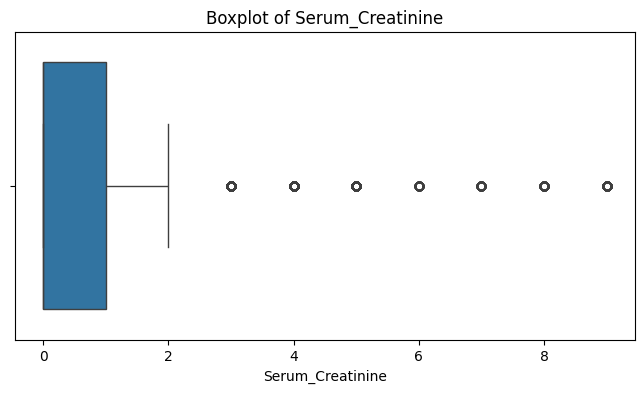

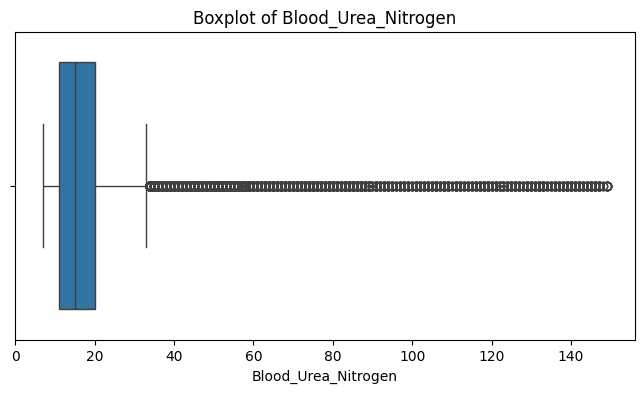

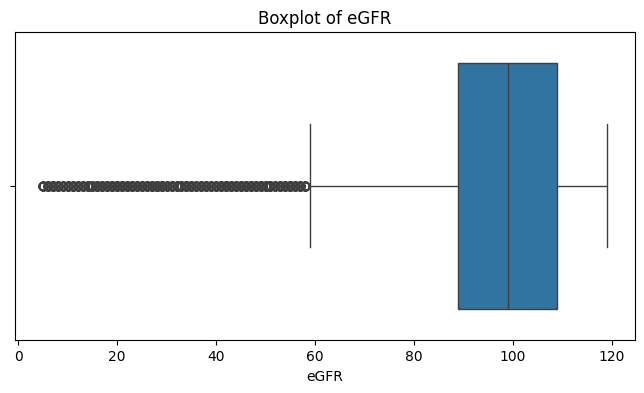

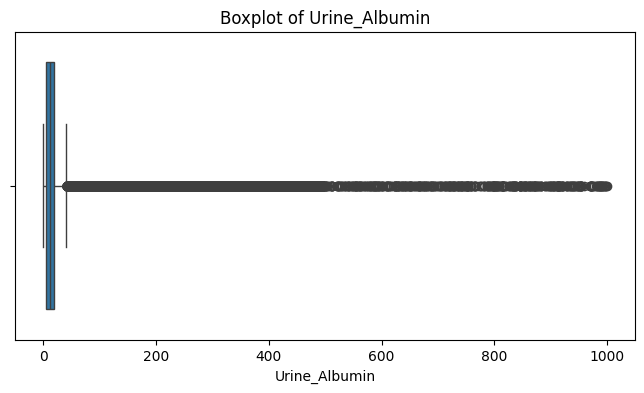

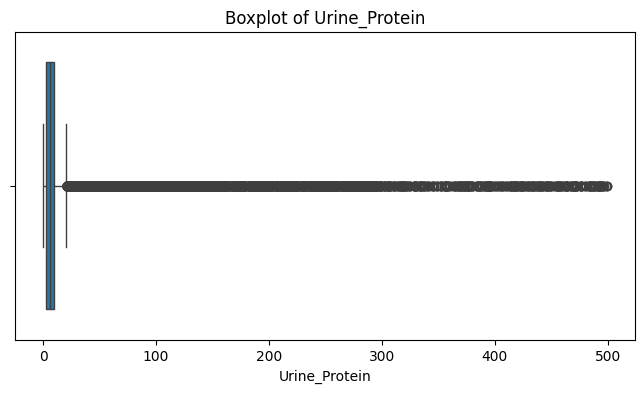

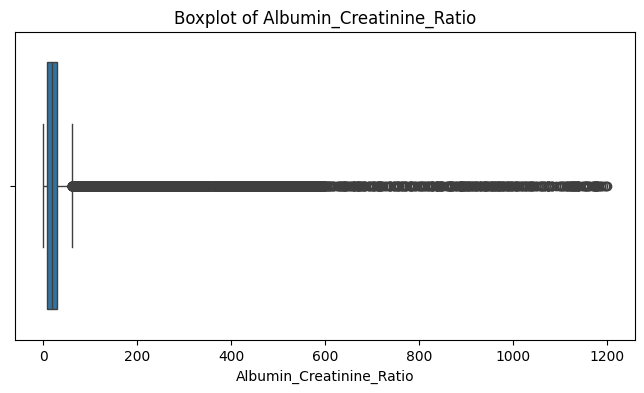

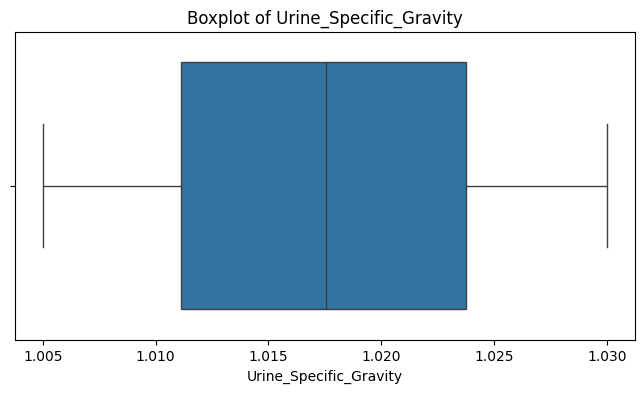

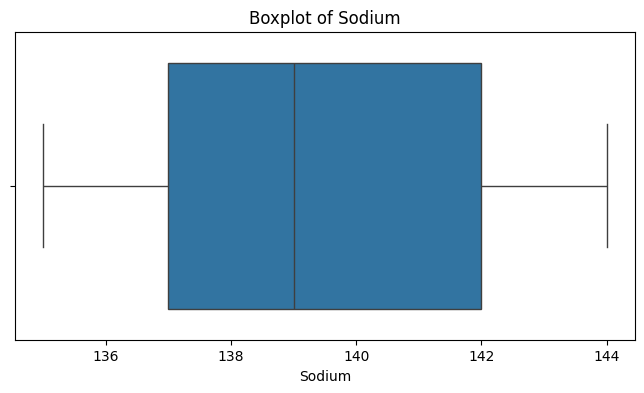

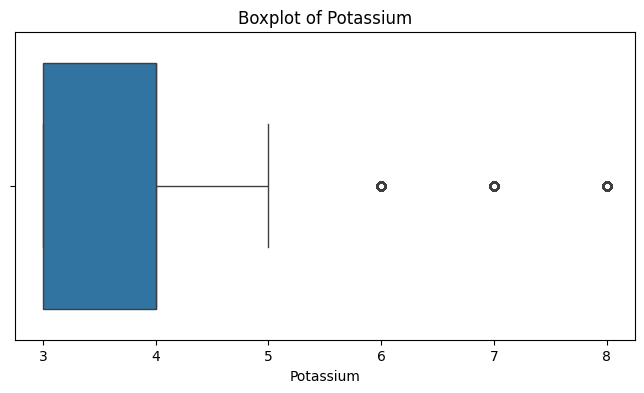

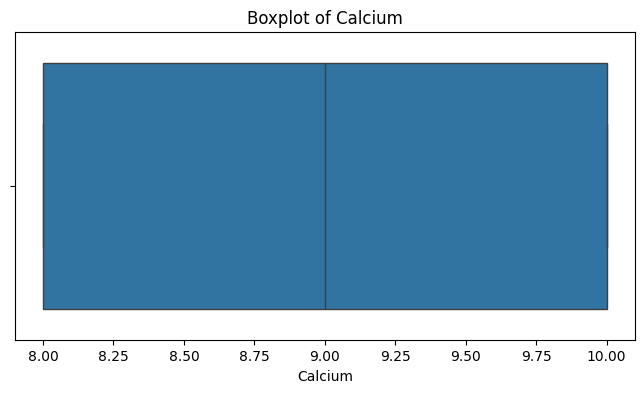

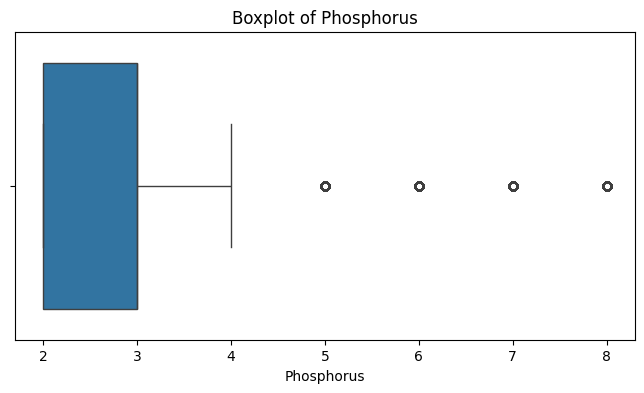

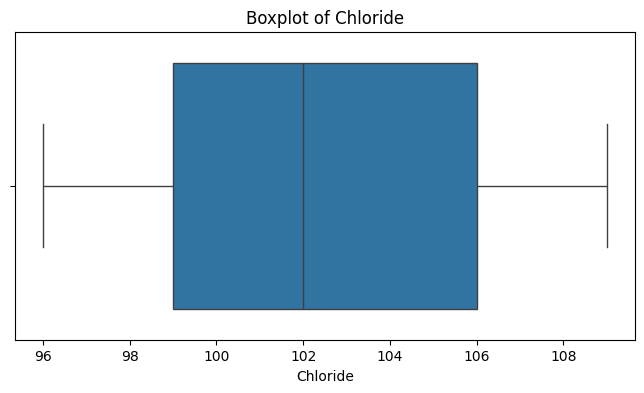

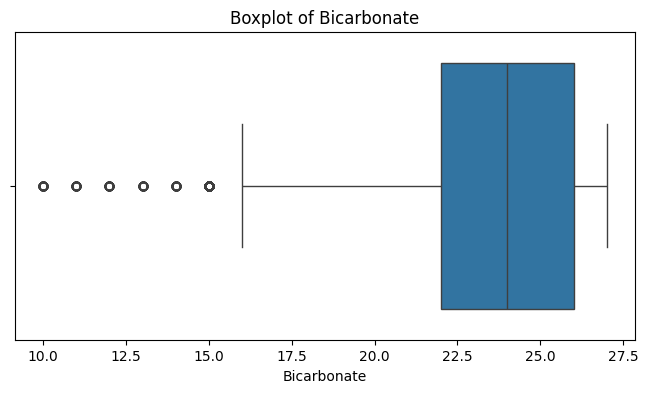

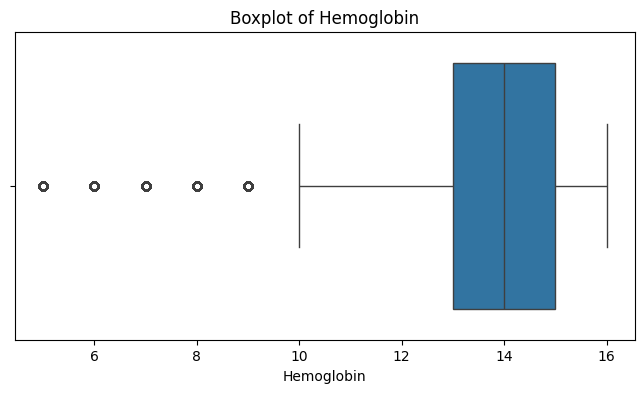

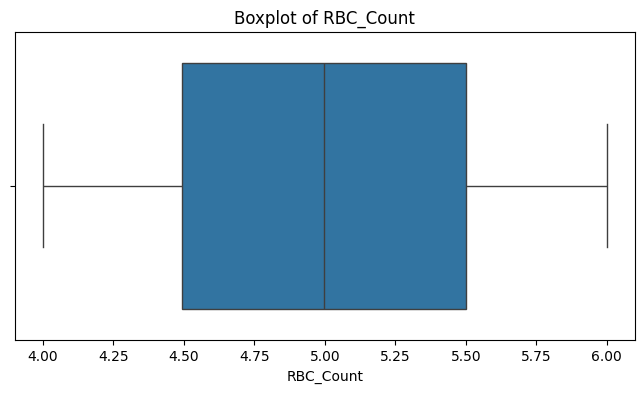

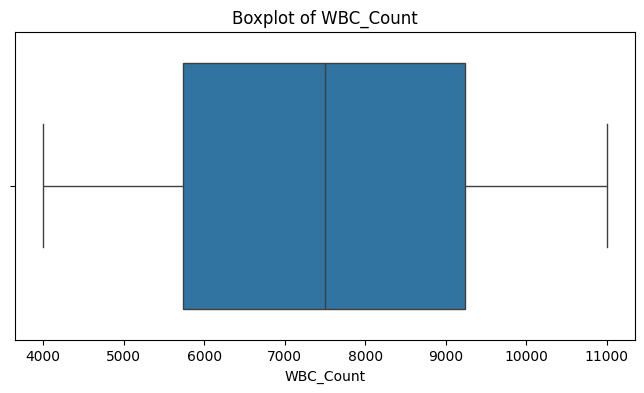

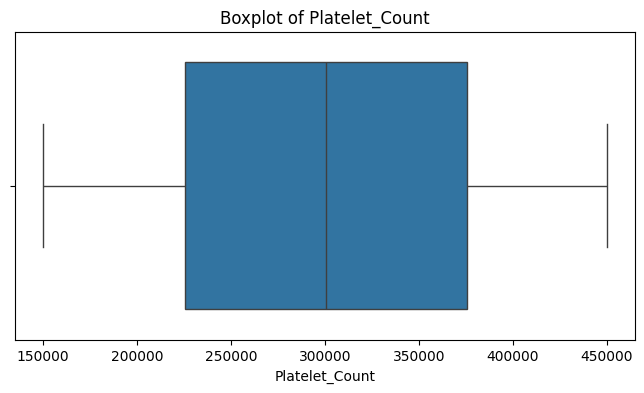

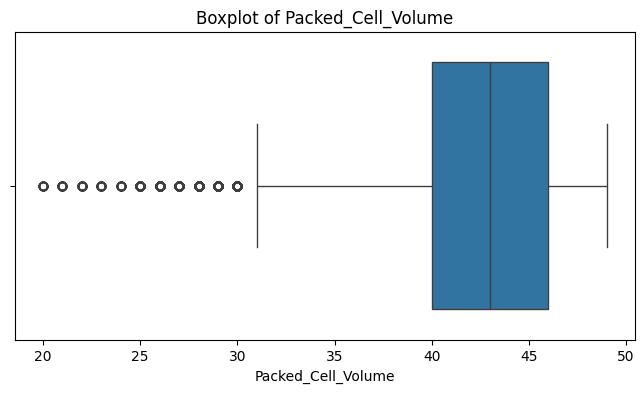

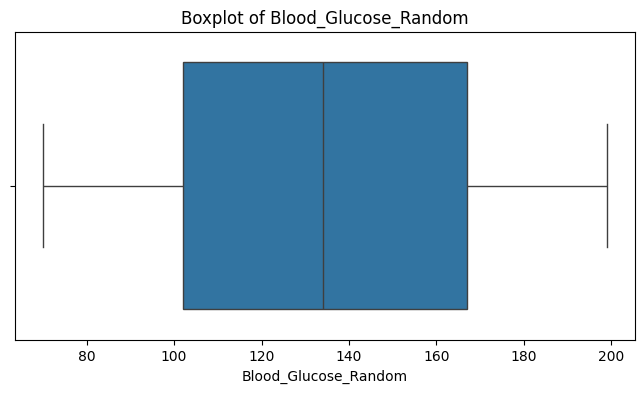

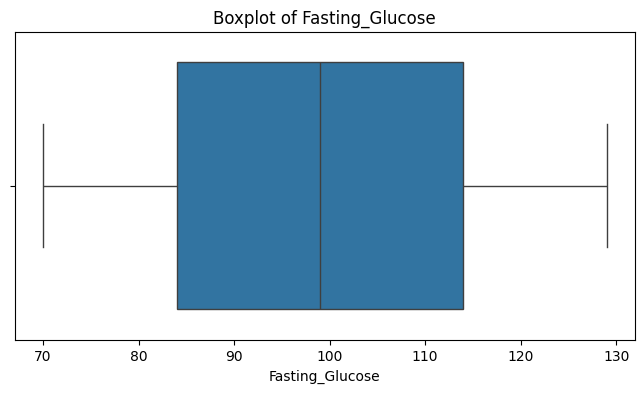

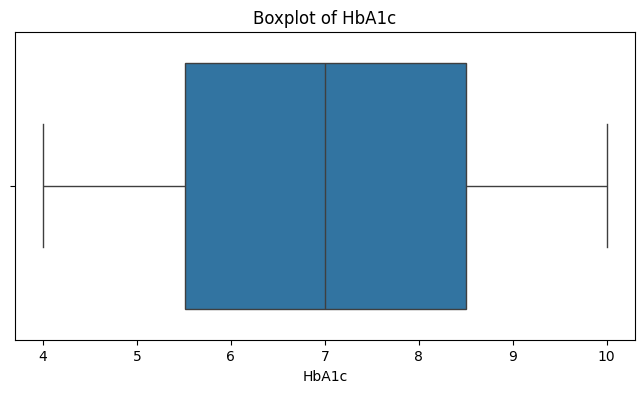

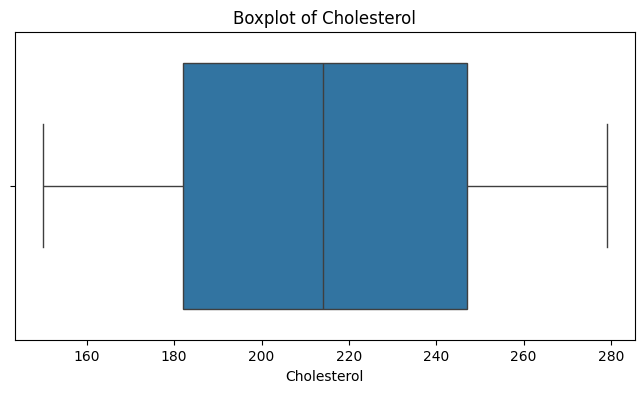

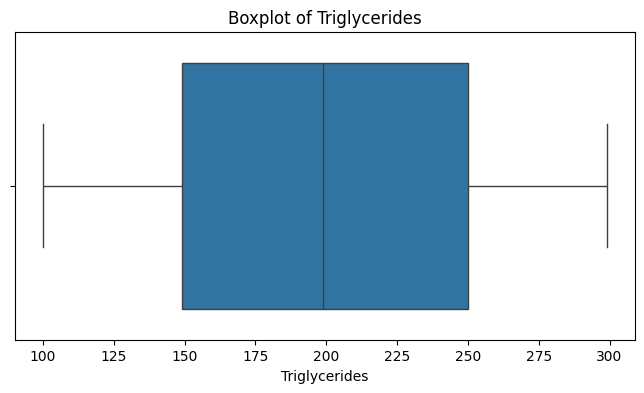

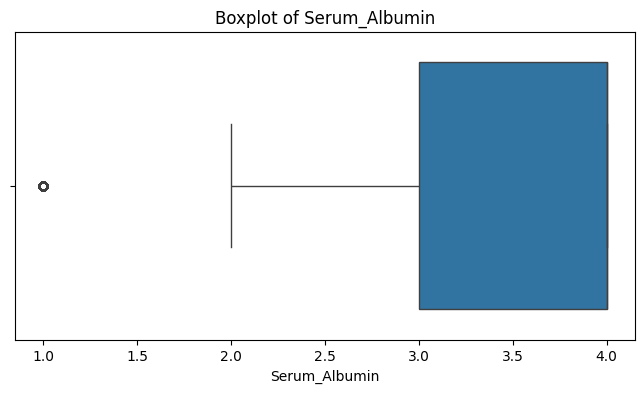

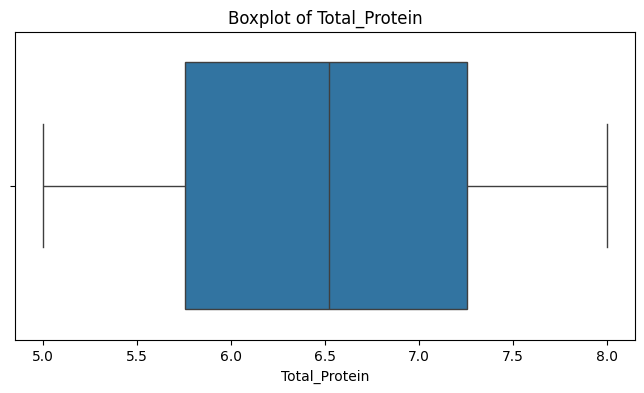

In [9]:
#Check for outliers using boxplots
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

In [10]:
#Apply log transformation to skewed features
# 1. Systolic_BP
# 2. Diastolic_BP
# 3. Blood_Urea_Nitrogen
# 4. eGFR
# 5. Urine_Albumin
# 6. Urine_Protein
# 7. Albumin_Creatinine_Ratio
skewed_features = ['Systolic_BP', 'Diastolic_BP', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio']
for feature in skewed_features:
    df_train[feature] = np.log1p(df_train[feature])

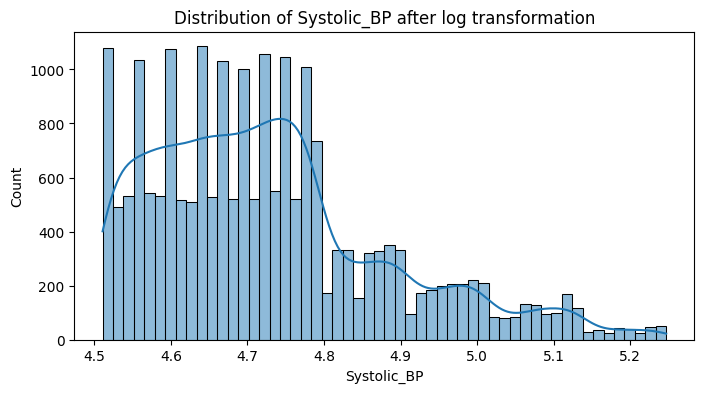

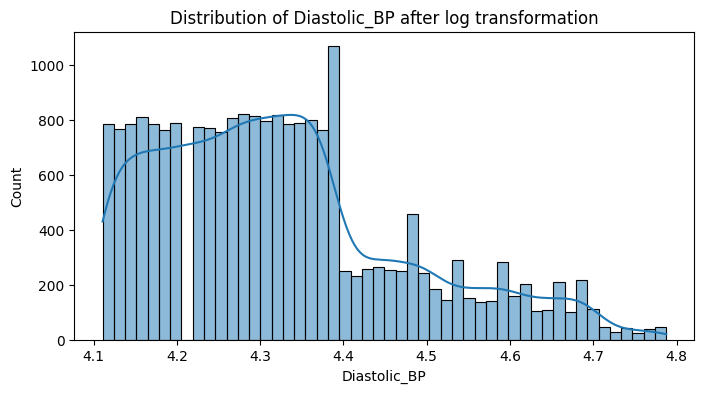

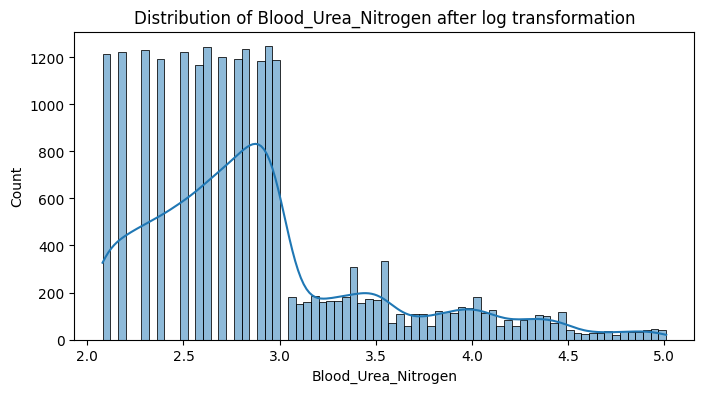

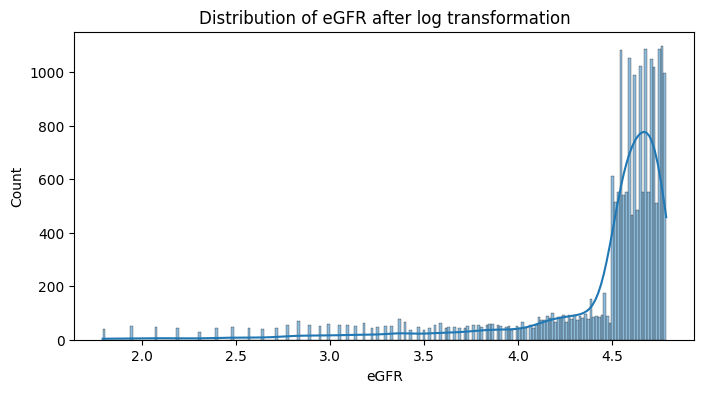

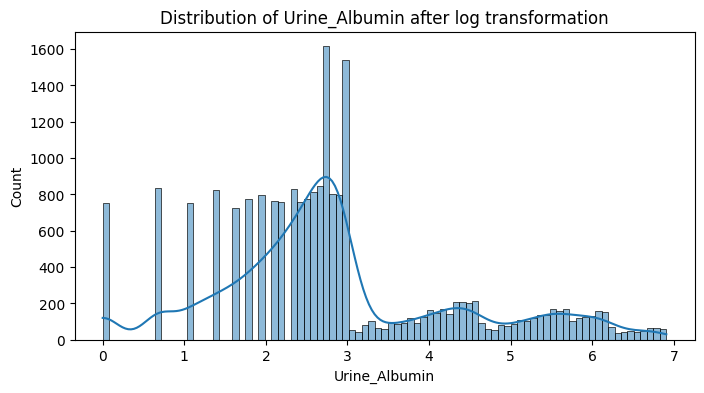

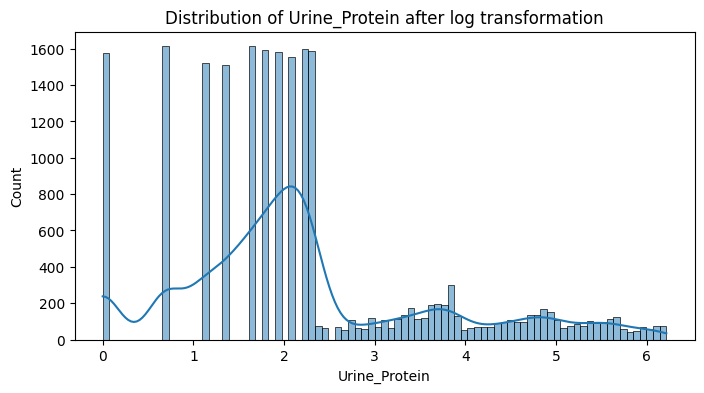

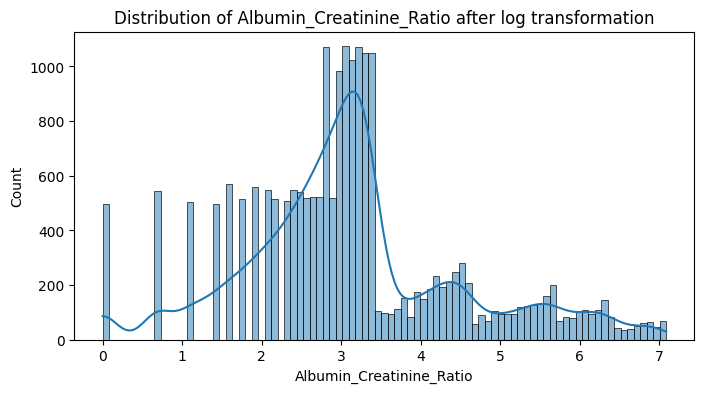

In [11]:
#plotting the ditribution of the skewed features after log transformation
for feature in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[feature], kde=True)
    plt.title(f'Distribution of {feature} after log transformation')
    plt.show()

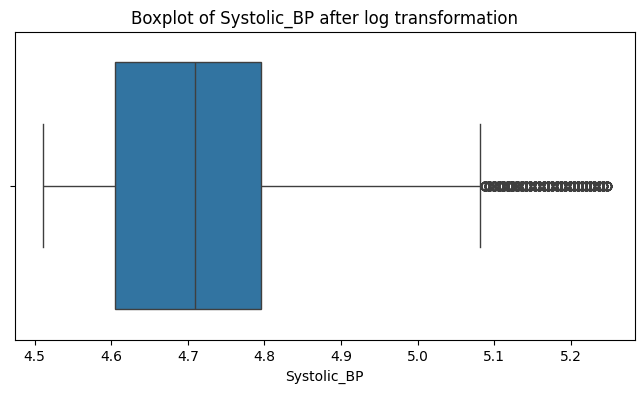

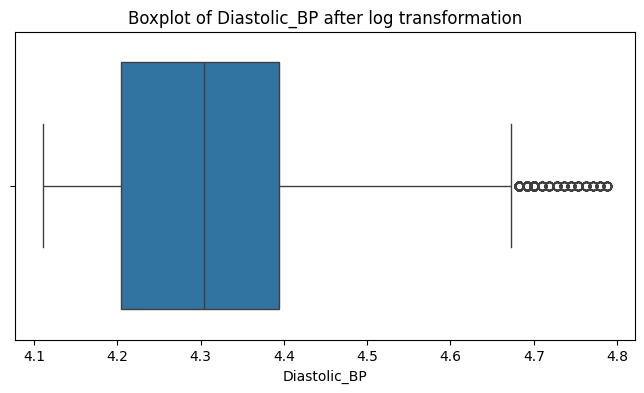

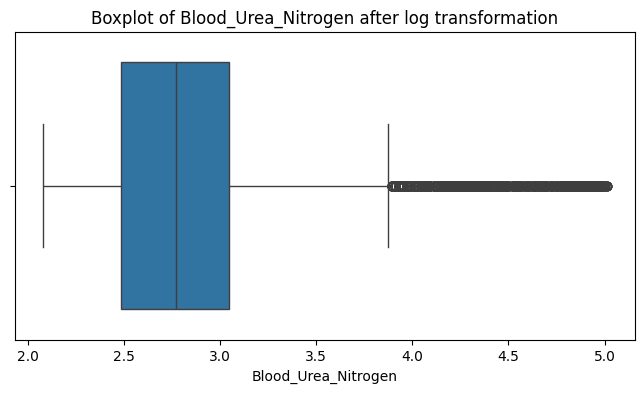

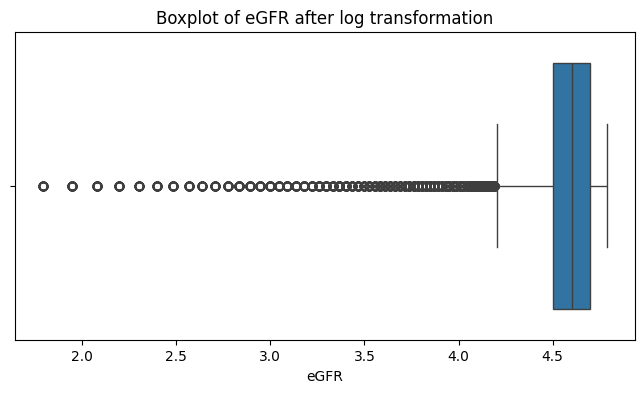

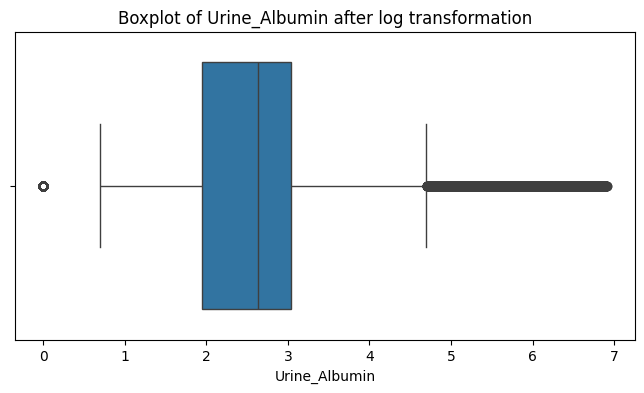

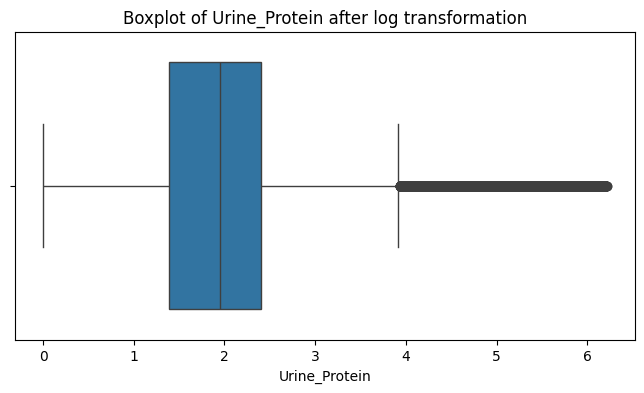

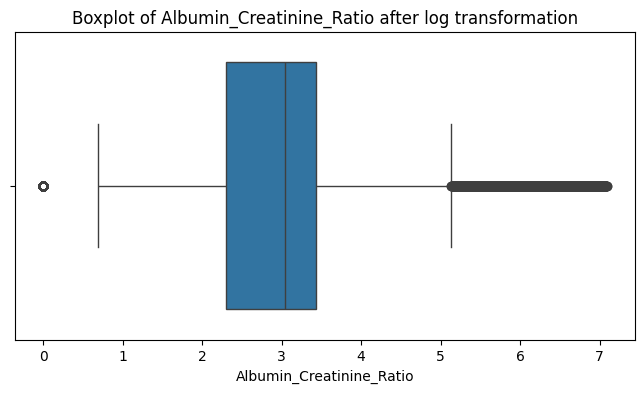

In [12]:
#Draw boxplots for the skewed features after log transformation
for feature in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Boxplot of {feature} after log transformation')
    plt.show()

### okay it seem that the effect of outlier data is become less

## Feature Engineering

### Now,Check correlation

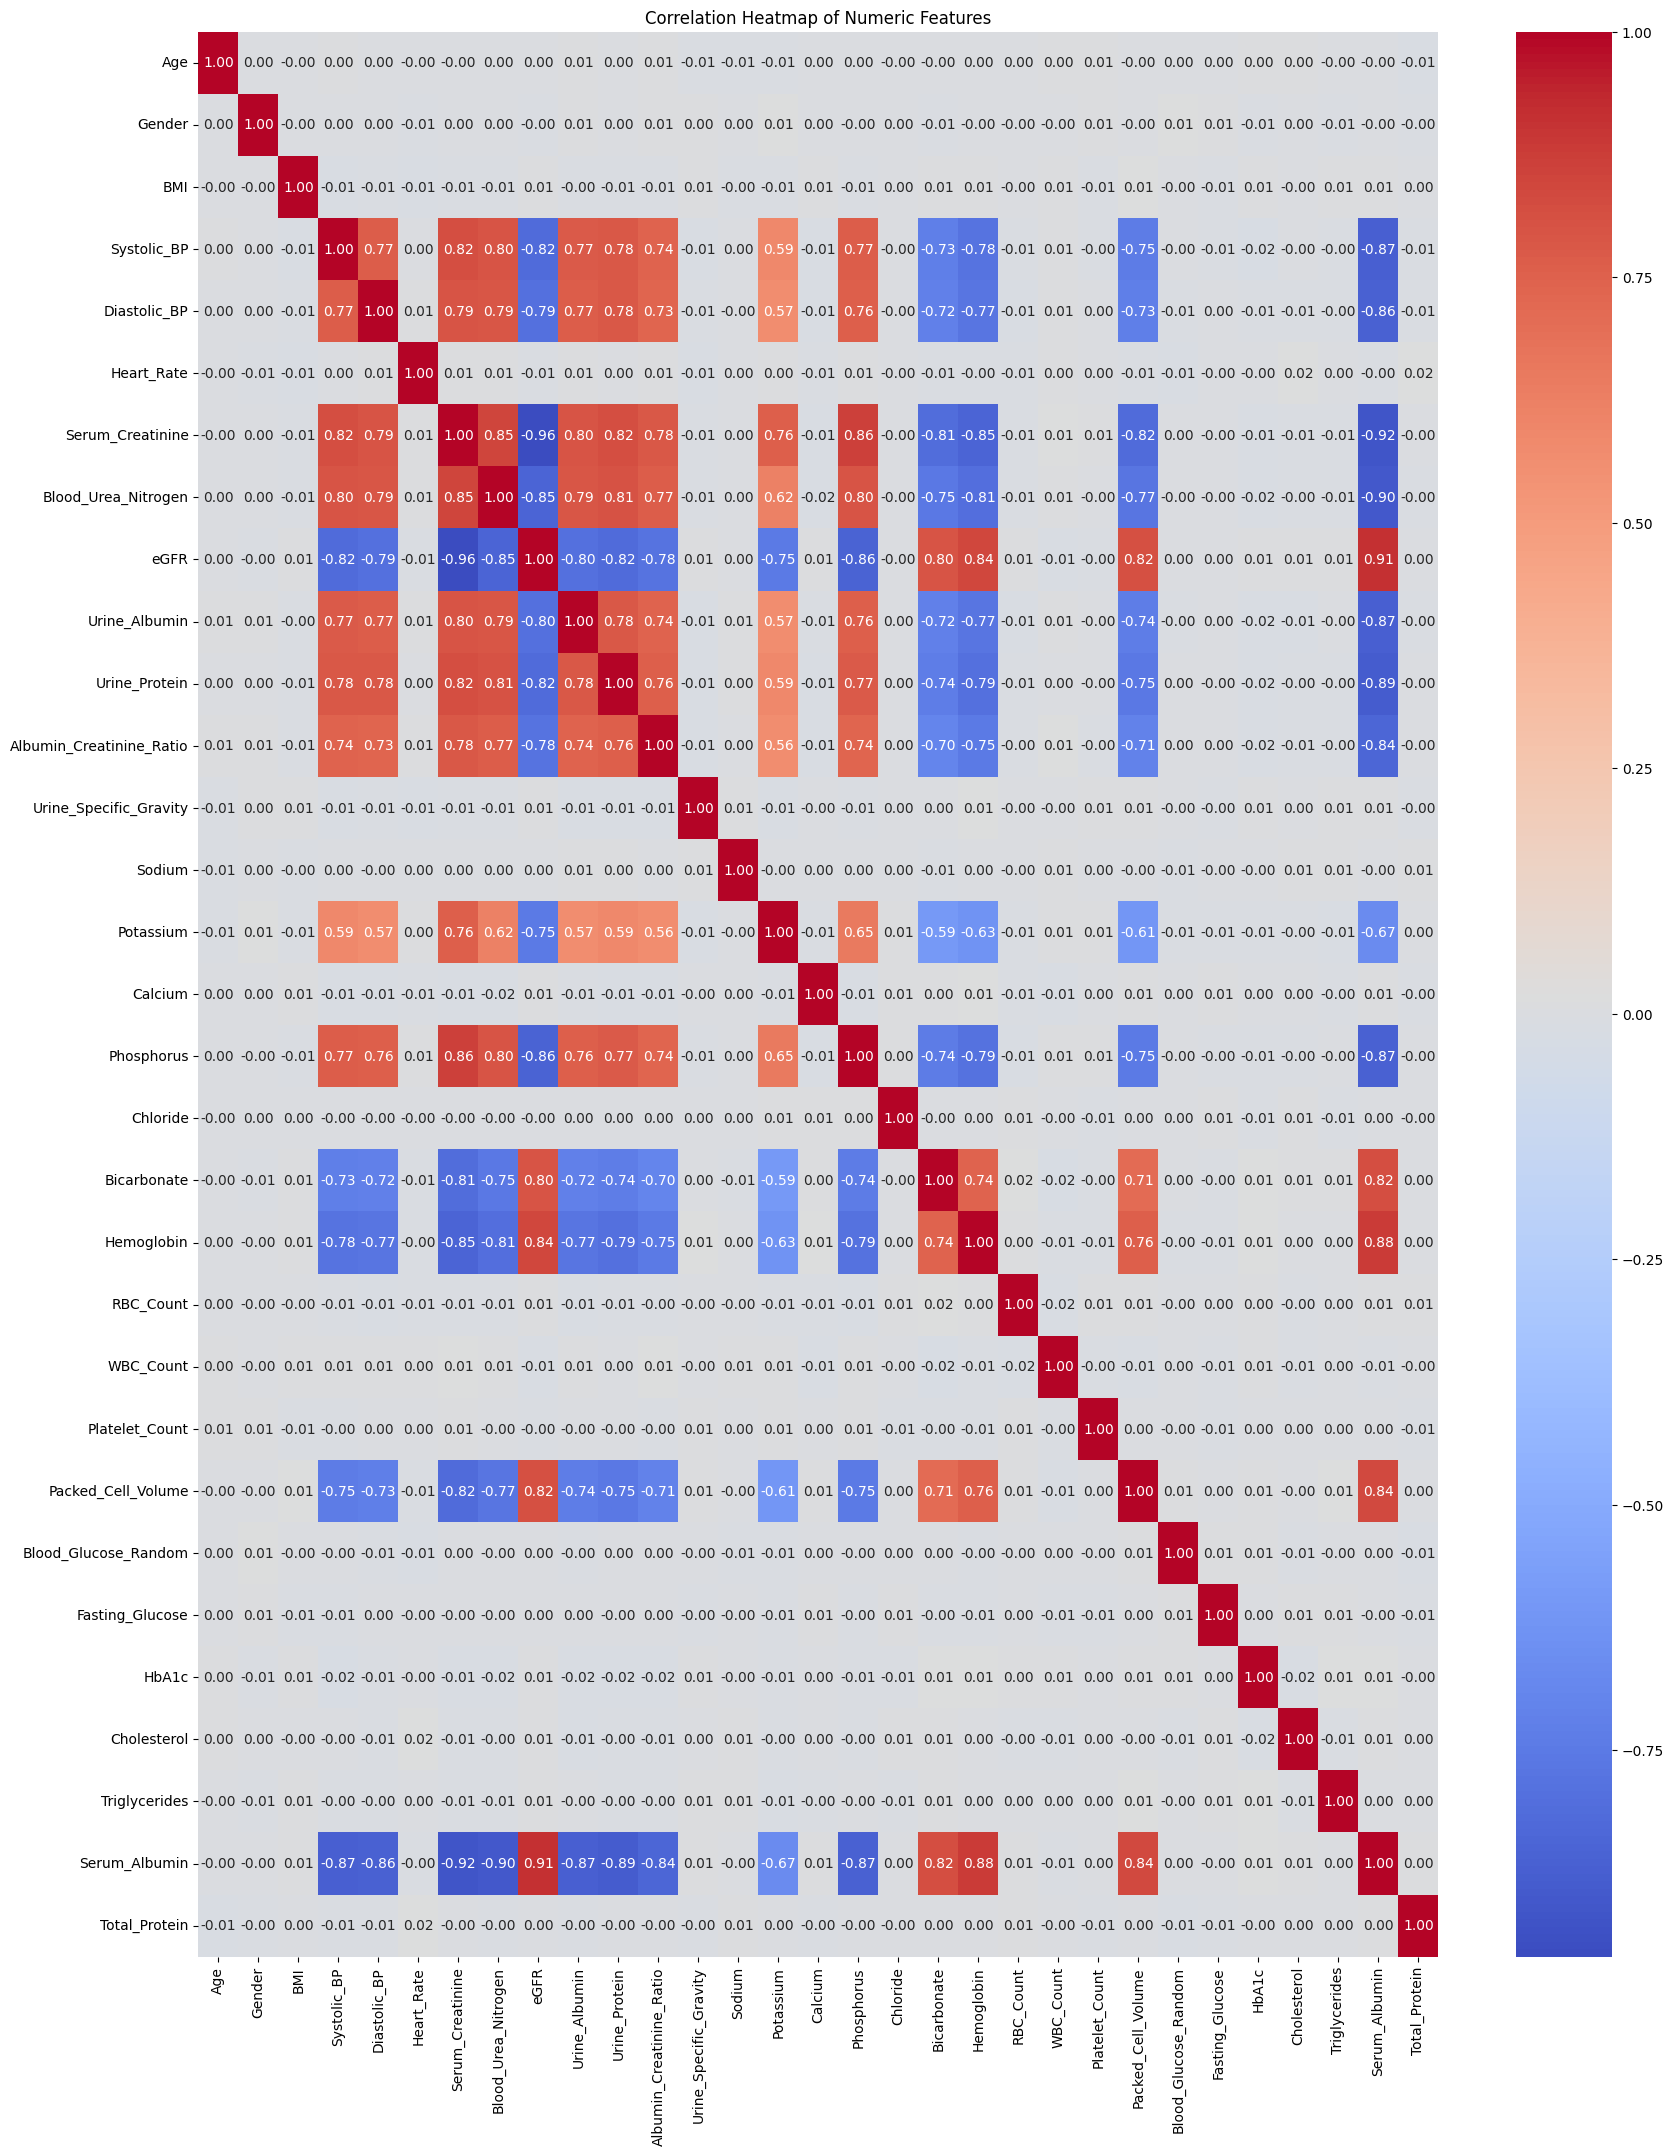

In [13]:
#correlation heatmap for numeric features
plt.figure(figsize=(20, 25))
numeric_features = df_train.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### We can see that data contain multicolinearity 

### Encode Featurs that contain {'Yes':1,'No':0}

In [14]:
#encode  ["Diabetes","Hypertension","Smoking_Status","Family_History_Kidney"] columns {'Yes': 1, 'No': 0}
df_train['Diabetes'] = df_train['Diabetes'].map({'Yes': 1, 'No': 0})
df_train['Hypertension'] = df_train['Hypertension'].map({'Yes': 1, 'No': 0})
df_train['Smoking_Status'] = df_train['Smoking_Status'].map({'Yes': 1, 'No': 0})
df_train['Family_History_Kidney'] = df_train['Family_History_Kidney'].map({'Yes': 1, 'No': 0})


In [15]:
df_train

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,4.584967,4.248495,99,0,2.564949,4.564348,...,96,7.547874,204,120,4,7.091259,1,1,1,1
1,Severe CKD (Stage 4),43,0,18,5.111988,4.615121,67,5,4.477337,3.367296,...,88,7.287338,166,277,2,7.875167,1,1,1,0
2,Healthy Kidney,77,0,32,4.762174,4.158883,101,0,2.833213,4.615121,...,82,9.114854,246,299,4,7.083558,0,0,1,0
3,Healthy Kidney,83,0,24,4.543295,4.330733,87,0,2.397895,4.624973,...,82,7.286450,173,285,4,6.428780,1,0,0,1
4,Healthy Kidney,38,1,19,4.718499,4.262680,92,0,2.397895,4.634729,...,106,8.376492,266,294,4,7.852894,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,Healthy Kidney,45,0,19,4.595120,4.143135,86,0,2.484907,4.753590,...,124,6.337256,255,275,4,6.536640,0,0,0,0
20996,Mild CKD (Stage 1–2),82,0,20,4.836282,4.406719,88,1,3.218876,4.262680,...,121,4.149633,207,297,3,6.707196,1,1,1,0
20997,Healthy Kidney,65,0,23,4.787492,4.143135,95,0,2.995732,4.663439,...,110,5.738345,249,196,4,6.576637,1,0,1,0
20998,Healthy Kidney,63,0,18,4.770685,4.248495,76,0,2.079442,4.700480,...,95,7.386147,278,231,4,6.030633,0,0,1,1


### see target unique values

In [16]:
#see target unique values and their counts
print(df_train['Target'].value_counts())

Target
Healthy Kidney              15744
Mild CKD (Stage 1–2)         2491
Moderate CKD (Stage 3)       1489
Severe CKD (Stage 4)          856
Kidney Failure (Stage 5)      420
Name: count, dtype: int64


### Draw Class Count

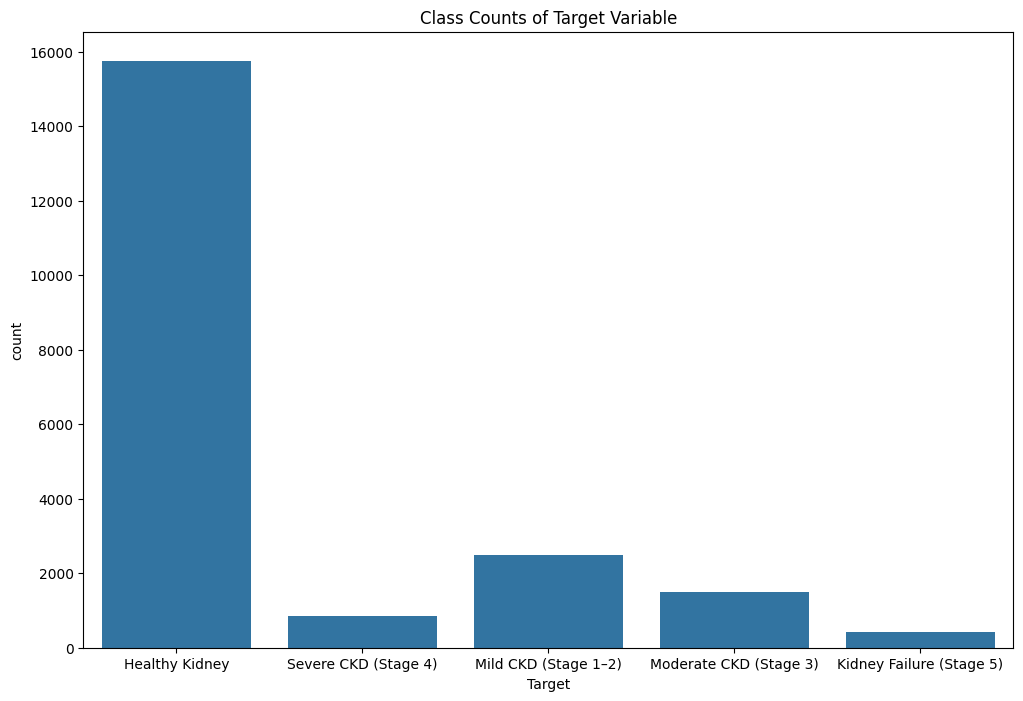

In [17]:
#Draw class Counts
plt.figure(figsize=(12, 8))
sns.countplot(x='Target', data=df_train)
plt.title('Class Counts of Target Variable')
plt.show()

### We can counclude that data is imbalanced so we will deal with weighted data

### set `class_weight='balanced'`

### Advanced Feature Enginering

### Handle Multicollinearity (Drop Redundant Features)
Based on the correlation heatmap, we are dropping features that are highly correlated with others to reduce multicollinearity:
* Dropping `Packed_Cell_Volume` (kept `Hemoglobin`)
* Dropping `Blood_Urea_Nitrogen` (kept `Serum_Creatinine`)
* Dropping `Urine_Protein` and `Albumin_Creatinine_Ratio` (kept `Urine_Albumin`)

In [18]:
# List of highly correlated features to drop
columns_to_drop = [
    'Packed_Cell_Volume', 
    'Blood_Urea_Nitrogen', 
    'Urine_Protein', 
    'Albumin_Creatinine_Ratio'
]

# Drop the columns from the training dataset
df_train = df_train.drop(columns=columns_to_drop)

# Verify the columns were dropped
print(f"Remaining number of columns: {df_train.shape[1]}")

Remaining number of columns: 32


### Encode `Target` feature

In [19]:
# encode Target using ordinal encoding from sklearn
# Healthy Kidney              3615
# Mild CKD (Stage 1–2)         575
# Moderate CKD (Stage 3)       318
# Severe CKD (Stage 4)         196
# Kidney Failure (Stage 5)      96
# Name: count, dtype: int64
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['Healthy Kidney', 'Mild CKD (Stage 1–2)', 'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 'Kidney Failure (Stage 5)']])
df_train['Target'] = ordinal_encoder.fit_transform(df_train[['Target']])


### Saving preprocessed Data frame 

In [20]:
#save the cleaned and preprocessed training dataset to a new CSV file
df_train.to_csv('Cleaned_Training_CKD_dataset.csv', index=False)

## Start Modeling

In [21]:
#read the cleaned training dataset
cleaned_df_train = pd.read_csv('Cleaned_Training_CKD_dataset.csv')

### Splitting Data

In [22]:
#split the cleaned training dataset into features and target
X= cleaned_df_train.drop('Target', axis=1)
y= cleaned_df_train['Target']

In [23]:
#Split the cleaned training dataset into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
#import classification report, confusion matrix, accuracy score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Try random forest Classifier

In [25]:
#Try multiclass classification using Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
print("Classification Report:\n", classification_report(y_val, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rf))
print("Accuracy Score:", accuracy_score(y_val, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3149
         1.0       1.00      1.00      1.00       498
         2.0       1.00      1.00      1.00       298
         3.0       1.00      1.00      1.00       171
         4.0       1.00      1.00      1.00        84

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200

Confusion Matrix:
 [[3149    0    0    0    0]
 [   0  498    0    0    0]
 [   0    0  298    0    0]
 [   0    0    0  171    0]
 [   0    0    0    0   84]]
Accuracy Score: 1.0


### Try Logistic regression

In [9]:
#try logistic regression model
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_val)
print("Classification Report:\n", classification_report(y_val, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_logreg))
print("Accuracy Score:", accuracy_score(y_val, y_pred_logreg))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.45      0.60       723
         1.0       0.13      0.27      0.18       115
         2.0       0.08      0.19      0.11        64
         3.0       0.06      0.26      0.09        39
         4.0       0.39      0.68      0.50        19

    accuracy                           0.41       960
   macro avg       0.31      0.37      0.30       960
weighted avg       0.71      0.41      0.49       960

Confusion Matrix:
 [[325 178 110 110   0]
 [ 26  31  27  29   2]
 [ 11  17  12  20   4]
 [  0  12   3  10  14]
 [  0   1   2   3  13]]
Accuracy Score: 0.40729166666666666


/home/ahmed-fayad/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Try XGBoost

In [26]:
#try multiclass classification using XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', scale_pos_weight=1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)
print("Classification Report:\n", classification_report(y_val, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_xgb))
print("Accuracy Score:", accuracy_score(y_val, y_pred_xgb))

/home/ahmed-fayad/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [08:54:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3149
         1.0       1.00      1.00      1.00       498
         2.0       1.00      1.00      1.00       298
         3.0       1.00      1.00      1.00       171
         4.0       1.00      1.00      1.00        84

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200

Confusion Matrix:
 [[3149    0    0    0    0]
 [   0  498    0    0    0]
 [   0    0  298    0    0]
 [   0    0    0  171    0]
 [   0    0    0    0   84]]
Accuracy Score: 1.0


### Save models

In [12]:
#save the best model to a file using joblib
import joblib
joblib.dump(xgb, 'best_model_xgb.pkl')

['best_model_xgb.pkl']

In [14]:
#Save random forest model to a file using joblib
joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

### Make same Pipeline in tset data to test model performance in data 

In [27]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load test data
df_test = pd.read_csv('Testing_CKD_dataset.csv')

# 2. Apply log transformation
skewed_features = ['Systolic_BP', 'Diastolic_BP', 'Blood_Urea_Nitrogen', 'eGFR', 
                   'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio']
for feature in skewed_features:
    df_test[feature] = np.log1p(df_test[feature])

# 3. Encode binary categorical features
binary_columns = ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']
for col in binary_columns:
    df_test[col] = df_test[col].map({'Yes': 1, 'No': 0})

# 4. Drop redundant features
columns_to_drop = ['Packed_Cell_Volume', 'Blood_Urea_Nitrogen', 
                   'Urine_Protein', 'Albumin_Creatinine_Ratio']
df_test.drop(columns=columns_to_drop, inplace=True)

# 5. Encode Target Feature (If it exists for evaluation)
if 'Target' in df_test.columns:
    ordinal_encoder = OrdinalEncoder(categories=[['Healthy Kidney', 'Mild CKD (Stage 1–2)', 
                                                  'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 
                                                  'Kidney Failure (Stage 5)']])
    df_test['Target'] = ordinal_encoder.fit_transform(df_test[['Target']])
    
    # Split features and target
    X_test = df_test.drop('Target', axis=1)
    y_test = df_test['Target']
else:
    X_test = df_test
    y_test = None

# Ensure column order matches training data globally
X_test = X_test[xgb.feature_names_in_] # Use feature names from the trained XGB model 

# 6. Load model & perform inference
loaded_model = joblib.load('best_model_xgb.pkl')
y_pred_test = loaded_model.predict(X_test)

# 7. Evaluate Performance (If True Labels exist)
if y_test is not None:
    print("Test Data Evaluation\n" + "-"*20)
    print("Classification Report:\n", classification_report(y_test, y_pred_test))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
    print("Accuracy Score:", accuracy_score(y_test, y_pred_test))

# Add predictions back to the test dataframe if you want to inspect them
df_test['Predicted_Target'] = y_pred_test

Test Data Evaluation
--------------------
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3615
         1.0       1.00      1.00      1.00       575
         2.0       1.00      1.00      1.00       318
         3.0       1.00      1.00      1.00       196
         4.0       1.00      1.00      1.00        96

    accuracy                           1.00      4800
   macro avg       1.00      1.00      1.00      4800
weighted avg       1.00      1.00      1.00      4800

Confusion Matrix:
 [[3615    0    0    0    0]
 [   0  575    0    0    0]
 [   0    0  318    0    0]
 [   0    0    0  196    0]
 [   0    0    0    0   96]]
Accuracy Score: 1.0
